In [13]:
from models.helper_PP_GP import prepare_data_from_parquet, train_model, compute_meta, plot_pp_overview, evaluate_test_metrics
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [14]:
np.random.seed(0)

In [15]:
parquet_path = "data/processed/cpr_gfw_2024.parquet"   # change to your path
train_coords, train_covs, train_y, test_coords, test_covs, test_y, scalers, df = prepare_data_from_parquet(parquet_path)
meta = compute_meta(df)

In [26]:
train_y.shape

(16121,)

In [16]:
print("N train:", train_coords.shape[0],
      "\ncoord_dim:", train_coords.shape[1],
      "\nn_covs:", train_covs.shape[1],
      "\ny_dim:", (train_y.shape[1] if train_y.ndim > 1 else 1))

assert train_coords.shape[0] == train_covs.shape[0] == train_y.shape[0]
assert test_coords.shape[0]  == test_covs.shape[0]  == test_y.shape[0]


N train: 16121 
coord_dim: 3 
n_covs: 2 
y_dim: 1


In [17]:
# train
model, losses = train_model(train_coords, train_covs, train_y,
                            M=300,       # inducing points
                            lr=1e-4,
                            num_steps=10000,
                            minibatch = min(1024, train_coords.shape[0]),
                            device="cpu"
                            )  # or "cuda" if available

9571.9229
9592.4199
9370.9912
10530.3887
10405.9385
9416.7627
9978.1582
8928.4297
9469.2744
8890.8799
9131.8281
8234.1924
8095.9209
8711.6230
8586.8887
8026.8340
8110.0801
8265.3975
8622.5703
7893.7954
8117.0625
8240.8896
7746.7451
8084.2710
7908.3667
8176.8193
7914.9678
7545.5669
8211.5967
8605.8955
7026.4849
7836.1812
7777.3135
7759.6592
7700.3892
7718.5859
8024.1953
7434.9937
8273.8789
7019.6685
7494.0791
7076.6582
7227.1270
7234.1318
7009.1709
7398.5801
7383.9097
7881.4819
7754.2324
7567.0933
7202.8423
7510.2021
7143.1377
7192.1753
7186.4209
7098.7393
6887.5161
6767.9126
6796.2837
7235.8081
7343.3354
8007.0361
6736.8076
6726.2246
6956.8447
6879.3657
7496.4702
7449.3789
6823.7275
6792.8530
6551.5430
6777.3657
7018.7104
7204.2754
6570.0200
6314.5908
6461.6006
6606.9844
7300.7144
6246.9873
6830.8481
6788.2007
7663.3604
6993.0273
6664.1855
6620.7373
6958.2607
6976.8813
6823.5596
7289.0024
6717.9673
6522.2861
6535.8467
6595.1138
6887.4907
6331.3472
6082.6265
6481.2793
6843.0864
7092.019

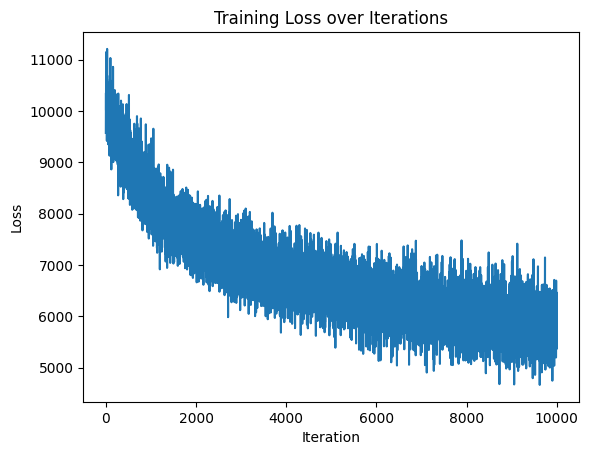

In [18]:
plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training Loss over Iterations")
plt.show()

In [19]:
# Merge train and test
all_coords = np.vstack([train_coords, test_coords])
all_covs = np.vstack([train_covs, test_covs])
all_y = np.concatenate([train_y, test_y])

# Sort by time (3rd column)
sort_idx = np.argsort(all_coords[:, 2])
all_coords_sorted = all_coords[sort_idx]
all_covs_sorted = all_covs[sort_idx]
all_y_sorted = all_y[sort_idx]
rate_mean, rate_p05, rate_p95 = model.predict_rate(all_coords_sorted, all_covs_sorted, num_samples=200)


In [20]:
# Convert test_coords[:,2] (normalized time) back to datetime
t_norm_test = test_coords[:, 2]
test_dates = pd.to_datetime(meta["t_min"]) + pd.to_timedelta(
    t_norm_test * (meta["t_max"] - meta["t_min"])
)

# Pick a random date from test_dates
rng = np.random.default_rng()
target_np = rng.choice(test_dates)  # numpy.datetime64
target_date = pd.to_datetime(target_np).date() # convert to datetime.date

print("Randomly chosen test date:", target_date)

Randomly chosen test date: 2024-01-26


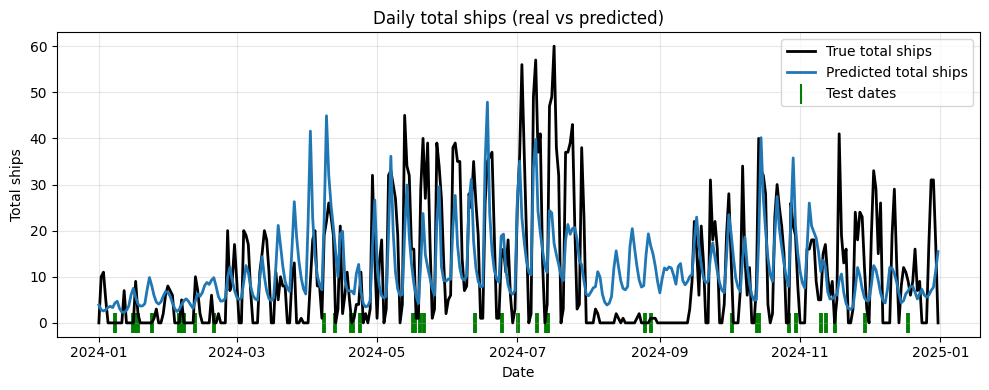

Selected closest available date: 2024-01-26 (normalized 0.071)


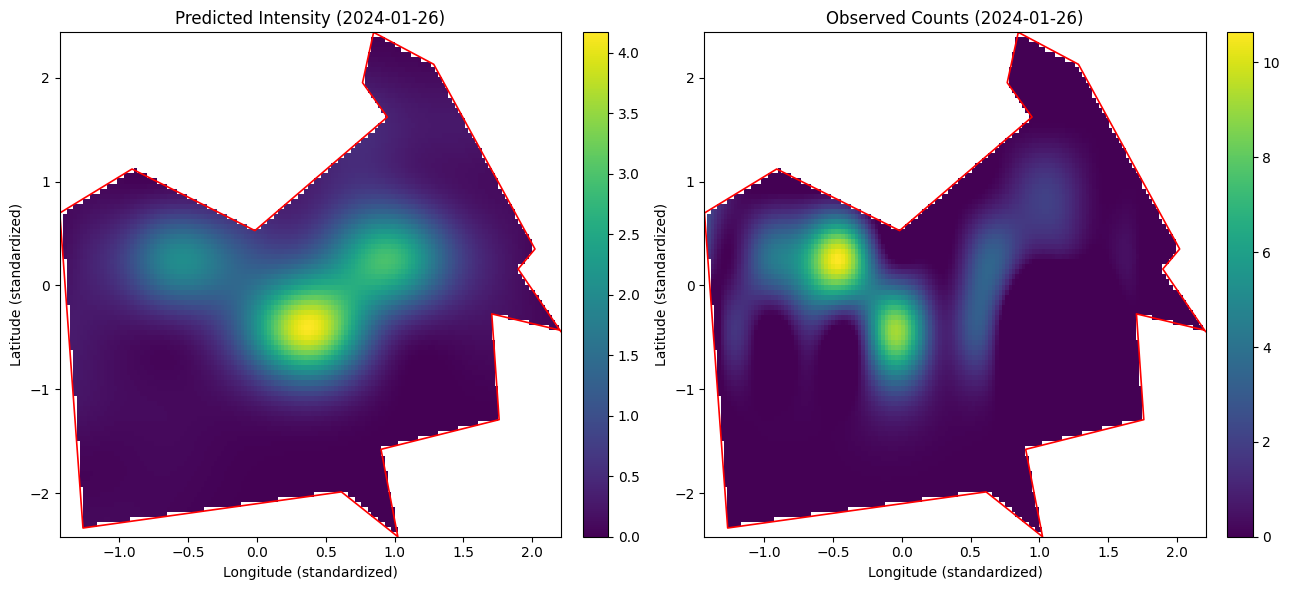

In [21]:
# Example usage
plot_pp_overview(
    model, 
    df,
    all_coords_sorted, 
    all_covs_sorted, 
    y_true=all_y_sorted, 
    meta=meta, 
    num_samples=800, 
    target_date=target_date,
    test_coords = test_coords,
    t_scaler = scalers["t_scaler"]
)


In [22]:
rate_mean_test, rate_p05_test, rate_p95_test = model.predict_rate(test_coords, test_covs, num_samples=200)

metrics = evaluate_test_metrics(test_y, rate_mean_test,test_dates)
print("Mean log-likelihood (per obs):", metrics["mean_ll_obs"])
print("Daily RMSE:", metrics["rmse_daily"])
print("Daily mean log-likelihood:", metrics["mean_ll_daily"])

Mean log-likelihood (per obs): -0.45611244592791556
Daily RMSE: 8.456748669948317
Daily mean log-likelihood: -5.19191314966928
